In [208]:
import zodiax as zdx
import jax.numpy as np

class Linear(zdx.Base):
    m : np.ndarray
    b : np.ndarray

    def __init__(self, m, b):
        self.m = m
        self.b = b

    def model(self, x):
        return self.m * x + self.b

linear = Linear(1., 1.)

In [209]:
import jax
@jax.jit
@jax.grad
def loss_fn(model, xs, ys):
    return np.square(model.model(xs) - ys).sum()

xs = np.array([1., 2., 3., 4., 5.])
ys = np.array([2., 4., 6., 8., 10.])

xs =   np.arange(5)
ys = 2*np.arange(5)
grads = loss_fn(linear, xs, ys)


In [210]:
import zodiax as zdx
from jax import numpy as np, scipy as scp


# A simple class to model 1d normals
class Normal(zdx.Base):
    mean      : np.ndarray
    scale     : np.ndarray
    amplitude : np.ndarray

    def __init__(self, mean, scale, amplitude):
        self.mean      = np.asarray(mean,      dtype=float)
        self.scale     = np.asarray(scale,     dtype=float)
        self.amplitude = np.asarray(amplitude, dtype=float)
    
    def model(self, width=10):
        xs = np.linspace(-width, width, 128)
        return self.amplitude * scp.stats.norm.pdf(xs, self.mean, self.scale)


# A class to store and model a set of normals
class NormalSet(zdx.Base):
    normals : dict
    width   : np.ndarray

    def __init__(self, means, scales, amplitude, names, width=10):
        normals = {}
        for i in range(len(names)):
            normals[names[i]] = Normal(means[i], scales[i], amplitude[i])
        self.normals = normals
        self.width = np.asarray(width, dtype=float)
    
    def __getattr__(self, key):
        if key in self.normals.keys():
            return self.normals[key]
        else:
            raise AttributeError(f"{key} not in {self.normals.keys()}")
    
    def model(self):
        return np.array([normal.model(self.width) 
            for normal in self.normals.values()]).sum(0)

sources = NormalSet([-1., 2.], [1., 2.], [2., 4.], ['alpha', 'beta'])

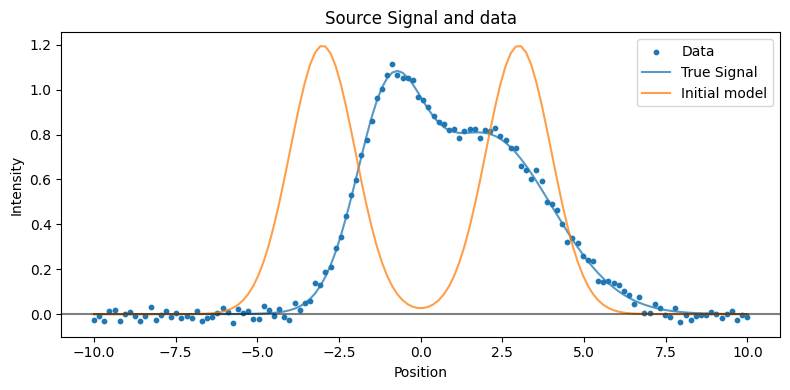

In [211]:
import jax.random as jr
import matplotlib.pyplot as plt

# Make some data by adding some noise
key = jr.PRNGKey(0)
true_signal = sources.model()
data = true_signal + jr.normal(key, sources.model().shape)/50

means = ['alpha.mean', 'beta.mean']
scales = ['alpha.scale', 'beta.scale']
amplitudes = ['alpha.amplitude', 'beta.amplitude']
means_init = [np.array(-3.), np.array(+3.)]

initial_model = sources.set([means, scales, amplitudes], 
    [means_init, np.array(1.), np.array(3.)])

plt.figure(figsize=(8, 4))
xs = np.linspace(-sources.width, sources.width, len(data))
plt.scatter(xs, data, s=10, label="Data")
plt.plot(xs, true_signal, alpha=0.75, label="True Signal")
plt.plot(xs, initial_model.model(), alpha=0.75, label="Initial model")
plt.axhline(0, color="k", alpha=0.5)
plt.title("Source Signal and data")
plt.xlabel("Position")
plt.ylabel("Intensity")
plt.legend()
plt.tight_layout()
plt.savefig("initial_model")
plt.show()

In [212]:
# Now lets construct a loss function
opt_parameters = [
    'alpha.mean', 'alpha.scale', 'alpha.amplitude',
    'beta.mean', 'beta.scale', 'beta.amplitude'
    ]
@zdx.filter_jit
@zdx.filter_value_and_grad(opt_parameters)
def loss_fn(model, data):
    return np.square(model.model() - data).sum()

# Compile to XLA
model = initial_model
loss, grads = loss_fn(model, data)

losses = []
for i in range(200):
    loss, grads = loss_fn(model, data)
    step = grads.multiply(opt_parameters, -1e-2)
    model = zdx.apply_updates(model, step)
    losses.append(loss)

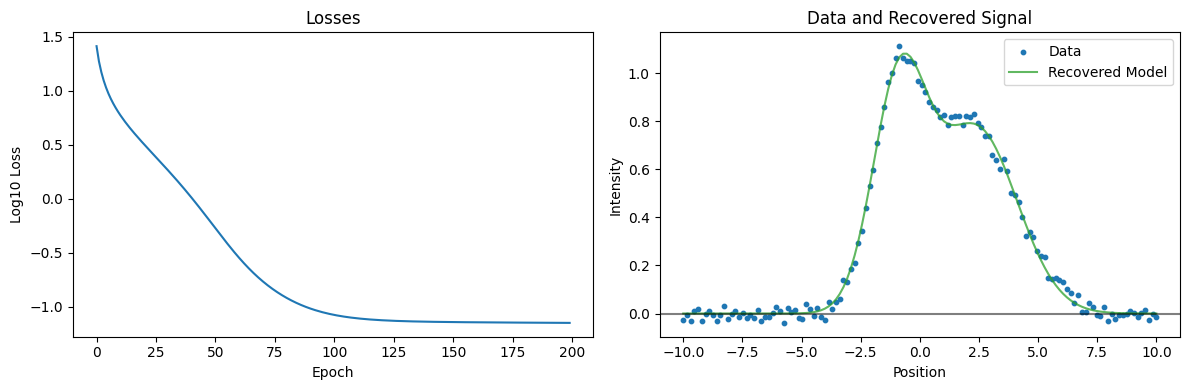

In [213]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(np.log10(np.array(losses)))
plt.title("Losses")
plt.xlabel("Epoch")
plt.ylabel("Log10 Loss")

plt.subplot(1, 2, 2)
plt.scatter(xs, data, s=10, label='Data')
plt.plot(xs, model.model(), alpha=0.75, label='Recovered Model',  c='tab:green')
plt.axhline(0, color="k", alpha=0.5)
plt.title("Data and Recovered Signal")
plt.xlabel("Position")
plt.ylabel("Intensity")
plt.legend()
plt.tight_layout()
plt.savefig("gd_fit")
plt.show()

In [214]:
import optax

# Get optax objcets
model = initial_model
optimiser, state = zdx.get_optimiser(model, opt_parameters, optax.adam(1e-1))

epochs = 200
losses = []
for i in range(epochs):
    loss, grads = loss_fn(model, data)
    step, state = optimiser.update(grads, state)
    model = zdx.apply_updates(model, step)
    losses.append(loss)

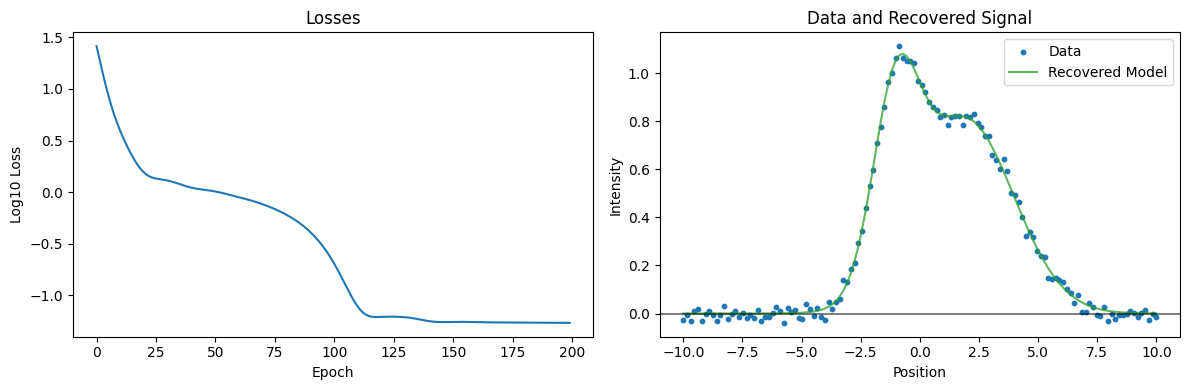

In [215]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(np.log10(np.array(losses)))
plt.title("Losses")
plt.xlabel("Epoch")
plt.ylabel("Log10 Loss")

plt.subplot(1, 2, 2)
plt.scatter(xs, data, s=10, label='Data')
plt.plot(xs, model.model(), alpha=0.75, label='Recovered Model',  c='tab:green')
plt.axhline(0, color="k", alpha=0.5)
plt.title("Data and Recovered Signal")
plt.xlabel("Position")
plt.ylabel("Intensity")
plt.legend()
plt.tight_layout()
plt.savefig("optax_fit")
plt.show()

In [216]:
# Estimating parameter uncertainty using FIM matrices
parameters = ['alpha.mean',      'beta.mean', 
              'alpha.scale',     'beta.scale', 
              'alpha.amplitude', 'beta.amplitude']

# Likelihod function
def chi2(X, model, data, noise=1):
    signal = perturb(X, model).model()
    return np.log10(np.square((signal - data) / noise).sum())

# Perturbation function
def perturb(X, model):
    for parameter, x in zip(parameters, X):
        model = model.add(parameter, x)
    return model


def calculate_covaraince(model, data):
    X = np.zeros(len(parameters))
    return -np.linalg.inv(jax.hessian(chi2)(X, model, data))

covariance_matrix = calculate_covaraince(model, data)
deviations = np.abs(np.diag(covariance_matrix))**0.5
print(deviations)

[0.20063384 0.81125915 0.30013818 0.5647679  1.2875816  1.4152523 ]


In [217]:
# import zodiax as zdx
# from jax import numpy as np, scipy as scp


# # A simple class to model 1d normals
# class Normal(zdx.Base):
#     params : np.ndarray

#     def __init__(self, mean, scale, amplitude):
#         self.params = np.asarray([mean, scale, amplitude], dtype=float)
        
#     def model(self, width=10):
#         mean, scale, ampl = self.params
#         xs = np.linspace(-width, width, 128)
#         return ampl * scp.stats.norm.pdf(xs, mean, scale)

# # A class to store and model a set of normals
# class NormalSet(zdx.Base):
#     normals : dict
#     width   : np.ndarray

#     def __init__(self, means, scales, amplitude, names, width=10):
#         normals = {}
#         for i in range(len(names)):
#             normals[names[i]] = Normal(means[i], scales[i], amplitude[i])
#         self.normals = normals
#         self.width = np.asarray(width, dtype=float)
    
#     def __getattr__(self, key):
#         if key in self.normals.keys():
#             return self.normals[key]
#         else:
#             raise AttributeError(f"{key} not in {self.normals.keys()}")
    
#     def model(self):
#         return np.array([normal.model(self.width) 
#             for normal in self.normals.values()]).sum(0)

# sources = NormalSet([-1., 2.], [1., 2.], [2., 4.], ['alpha', 'beta'])

In [242]:
1/50

0.02

In [246]:
# parameters = ['alpha.params', 'beta.params', 'width']
# parameters = ['alpha.params', 'beta.params']
parameters = ['alpha.mean',      'beta.mean', 
              'alpha.scale',     'beta.scale', 
              'alpha.amplitude', 'beta.amplitude']
model = sources

def decompose(model, parameters):
    # Get shapes
    get_shape = lambda arr: (1,) if arr.shape == () else arr.shape
    shapes = [get_shape(model.get(parameter)) for parameter in parameters]

    # Get sizes
    sizes = np.array([np.prod(np.array(shape)) for shape in shapes])

    # Get indexes
    indexes = [sizes[:i].sum() for i in range(len(sizes))]

    # Construct vector and deconstruct function
    X = np.zeros(sizes.sum())
    deconstruct = lambda X: [np.squeeze(X[index : index + size].reshape(shape))
            for index, size, shape in zip(indexes, sizes, shapes)]
    return X, deconstruct

X, construct = decompose(model, parameters)
construct(X)

# Likelihod function
# def chi2(X, model, data, parameters, deconstruct, noise=1):
#     signal = perturb(X, model, parameters, deconstruct).model()
def chi2(signal, data, noise=1):
    # return np.log10(np.square((signal - data) / noise).sum())
    # return np.square((signal - data) / noise).sum()
    return -0.5 * np.square((signal - data) / noise).sum()

def likelihood(signal, data, noise=1):
    return np.exp(-0.5 * np.square((signal - data) / noise).sum())

# Perturbation function
def perturb(X, model, parameters, deconstruct):
    for parameter, x in zip(parameters, deconstruct(X)):
        model = model.add(parameter, x)
    return model


def calculate_covaraince(model, data, parameters):
    X, deconstruct = decompose(model, parameters)
    def perturb(X, model):
        for parameter, x in zip(parameters, deconstruct(X)):
            model = model.add(parameter, x)
        # return chi2(model.model(), data)
        return likelihood(model.model(), data)
    return -np.linalg.inv(jax.hessian(perturb)(X, model))
    # return -np.linalg.inv(jax.hessian(chi2)(X, model, data))
    # return -np.linalg.inv(jax.hessian(chi2)(X, model, data, parameters, deconstruct))

# cov = calculate_covaraince(model, data, parameters)
covariance_matrix = calculate_covaraince(model, data, parameters)
deviations = np.abs(np.diag(covariance_matrix))**0.5
print(deviations)

[0.4173388  1.4128382  0.51386595 1.0155256  2.2791939  2.4423397 ]


In [237]:
np.diag(covariance_matrix)**0.5

Array([0.9107641, 3.0756571, 1.1131213, 2.2085981, 4.9602766, 5.3293433],      dtype=float32)

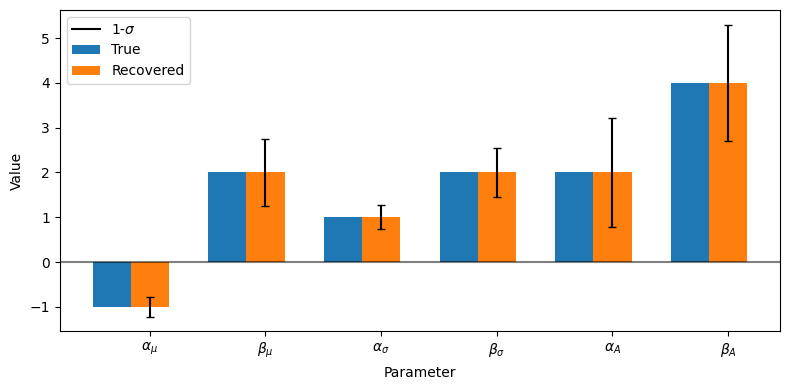

In [220]:
# Plotting
true_values = sources.get(parameters)
recoverd_parameters = model.get(parameters)
# true_values = np.array([sources.alpha.params, sources.beta.params]).flatten()
# recoverd_parameters = np.array([model.alpha.params, model.beta.params]).flatten()

formatted = [r"$\alpha_\mu$",    r"$\beta_\mu$",
             r"$\alpha_\sigma$", r"$\beta_\sigma$",
             r"$\alpha_A$",      r"$\beta_A$"]

plt.figure(figsize=(8, 4))
# xs = np.arange(len(parameters))
xs = np.arange(6)
plt.bar(xs, true_values, tick_label=formatted, width=0.33, label='True')
plt.bar(xs+0.33, recoverd_parameters, tick_label=formatted, yerr=deviations, 
    width=0.33, label='Recovered', capsize=3)
plt.plot([], c='k', label='1-$\sigma$')
plt.axhline(0, color="k", alpha=0.5)
plt.legend(loc=2)
plt.xlabel("Parameter")
plt.ylabel("Value")
plt.tight_layout()
plt.savefig("fisher_fit")
plt.show()

In [35]:
# Numpyro
import numpyro as npy
import numpyro.distributions as dist
import jax.random as jr
import chainconsumer as cc

def sampling_fn(data, model):

    # Define paths to the parametrs
    paths = ["alpha.mean",      "beta.mean", 
             "alpha.scale",     "beta.scale",
             "alpha.amplitude", "beta.amplitude"]

    # Define priors
    values = [npy.sample("$\\alpha_\mu$",    dist.Normal(0, 5)), 
              npy.sample("$\\beta_\mu$",     dist.Normal(0, 5)),
              npy.sample("$\\alpha_\sigma$", dist.HalfNormal(5)), 
              npy.sample("$\\beta_\sigma$",  dist.HalfNormal(5)),
              npy.sample("$\\alpha_A$",      dist.Normal(0, 5)), 
              npy.sample("$\\beta_A$",       dist.Normal(0, 5))]

    # dx = 50
    # values = [npy.sample("$\\alpha_\mu$",    dist.Uniform(-dx, dx)), 
    #           npy.sample("$\\beta_\mu$",     dist.Uniform(-dx, dx)),
    #           npy.sample("$\\alpha_\sigma$", dist.Uniform(0, dx)), 
    #           npy.sample("$\\beta_\sigma$",  dist.Uniform(0, dx)),
    #           npy.sample("$\\alpha_A$",      dist.Uniform(-dx, dx)), 
    #           npy.sample("$\\beta_A$",       dist.Uniform(-dx, dx))]
    
    # Sample data
    with npy.plate("data", len(data)):
        model_sampler = dist.Normal(
            model.set_and_call(paths, values, "model")
            )
        return npy.sample("Sampler", model_sampler, obs=data)

In [36]:
# Using the model above, we can now sample from the posterior distribution
# using the No U-Turn Sampler (NUTS).
sampler = npy.infer.MCMC(
    npy.infer.NUTS(sampling_fn),
    num_warmup=5000,
    num_samples=5000,
    progress_bar=True,
)
%time sampler.run(jr.PRNGKey(0), data.flatten(), model)

sample: 100%|██████████| 10000/10000 [00:02<00:00, 3913.82it/s, 31 steps of size 1.67e-01. acc. prob=0.92]


CPU times: user 2.58 s, sys: 68.8 ms, total: 2.64 s
Wall time: 2.64 s


In [37]:
parameters = ['alpha.mean',      'beta.mean', 
              'alpha.scale',     'beta.scale', 
              'alpha.amplitude', 'beta.amplitude']

formatted = [r"$\alpha_\mu$",    r"$\beta_\mu$",
             r"$\alpha_\sigma$", r"$\beta_\sigma$",
             r"$\alpha_A$",      r"$\beta_A$"]

samples = sampler.get_samples()
truth = {}
for i in range(len(formatted)):
    truth[formatted[i]] = sources.get(parameters[i])
MLE = model.get(parameters)

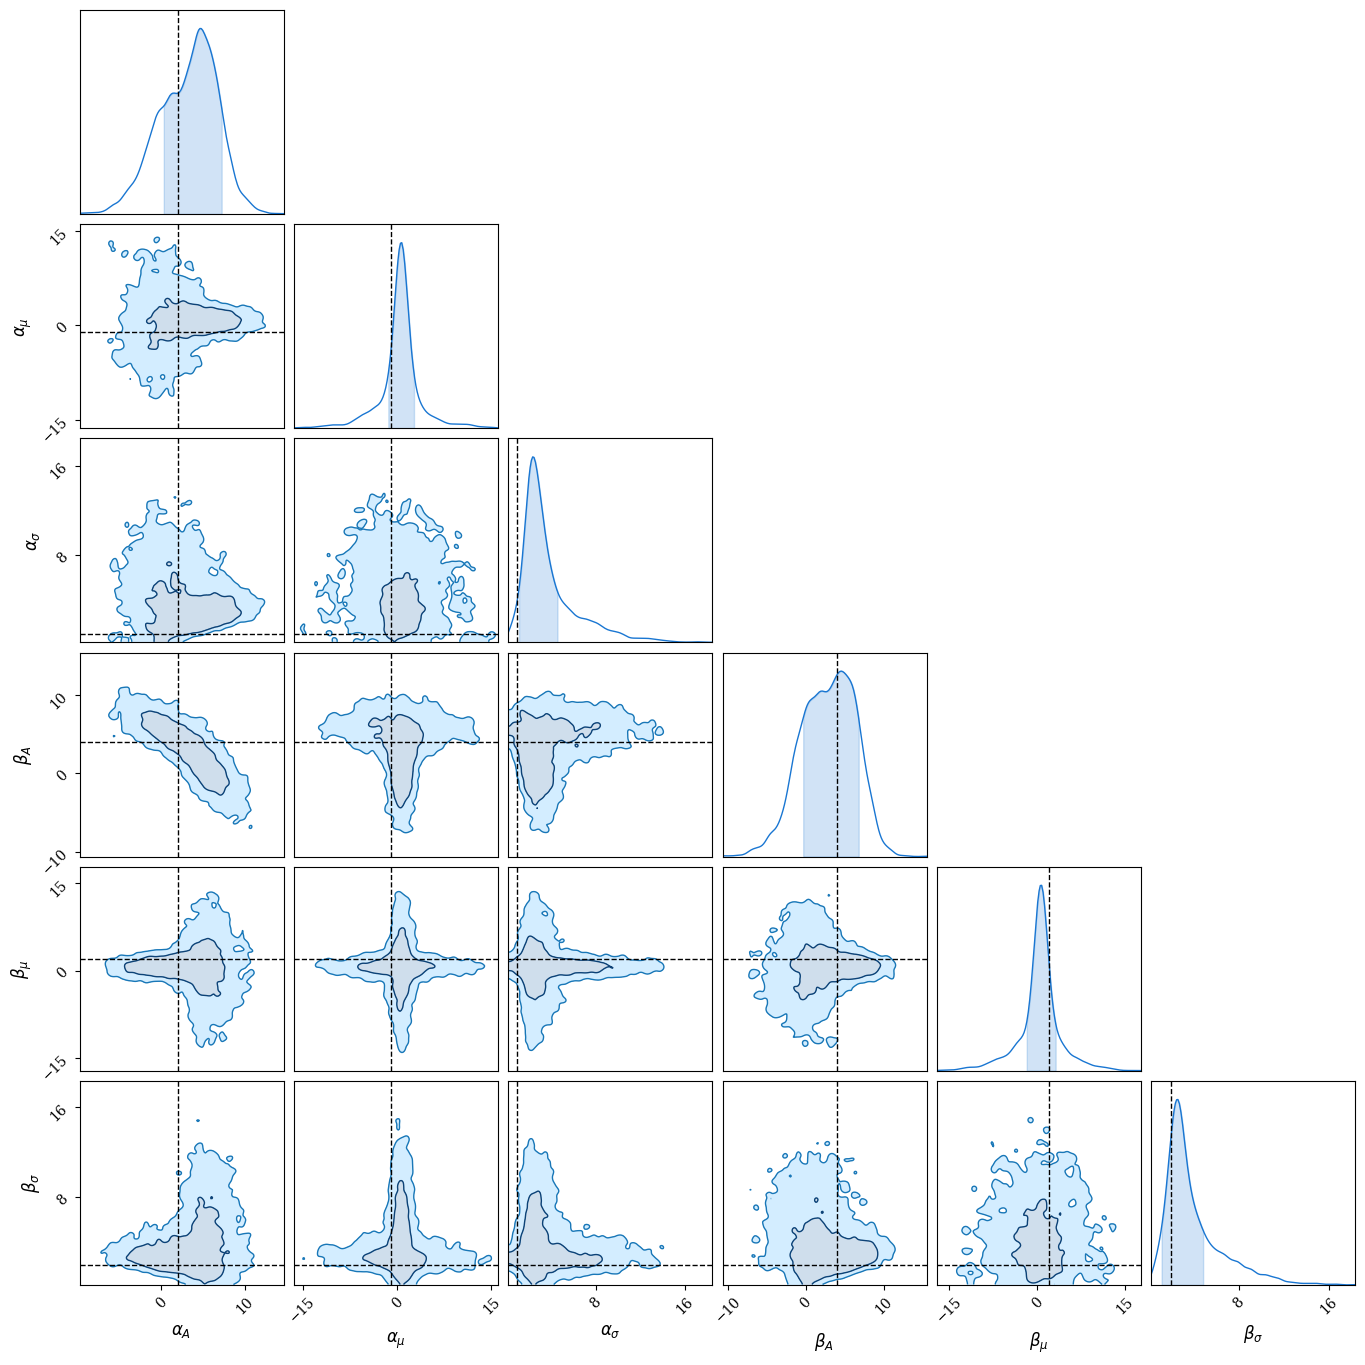

In [38]:
chain = cc.ChainConsumer()
chain.add_chain(samples)
# chain.add_covariance(MLE, covariance_matrix) #, parameters=param_names, name='Initial')
chain.configure(
    serif=True, shade=True, bar_shade=True, shade_alpha=0.2, spacing=1.0, max_ticks=3
)

fig = chain.plotter.plot(truth=truth)
fig.set_size_inches((15, 15))
fig.savefig("hmc_fit")

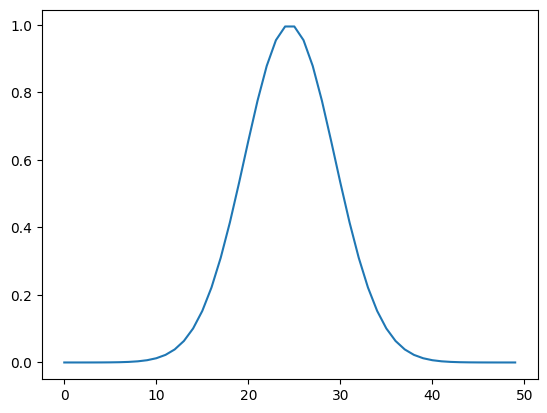

200074.4


(0.0, 0.41671419458683656)

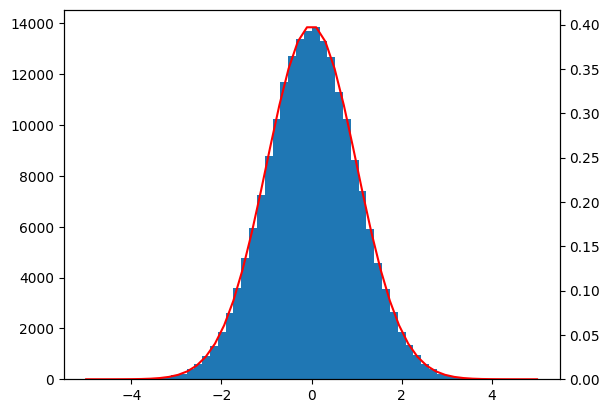

In [272]:
import jax.scipy as jsp
import jax.random as jr

def log_prior(distribution, mean, std):
    return np.square((mean - distribution) / std).sum()

def probs(x, mean, std):
    return np.exp(-0.5*np.square((mean - x) / std))

mean = 0
std = 1

xs = np.linspace(-5, 5)
prob = jsp.stats.norm.pdf(xs, loc=mean, scale=std)
dist = mean + std*jr.normal(jr.PRNGKey(0), (int(2e5),))

plt.plot(probs(xs, mean, std))
plt.show()

print(log_prior(dist, mean, std))

ax = plt.subplot(1, 1, 1)
ax.hist(dist, bins=51)
ax2 = ax.twinx()
ax2.plot(xs, prob, c='r')
ax2.set_ylim(0)